

```
# This is formatted as code
```

# Linear Classification

 Implement Linear Classification using pytorch. This consists of having fully connected layers connected one after the other and ReLu activation functions between them.
 
 Build a neural network with a minimun of 2 layers in order to do classification.

Permit the notebook to access your drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
import numpy as np
import torch.utils.data as utils
import time
import pdb
from torch.utils.data.sampler import SubsetRandomSampler
%matplotlib inline

torch.manual_seed(1)    # reproducible

Get the dataset

In [2]:
def get_train_valid_loader(data_dir='../data',
                           batch_size=64,
                           augment=False,
                           random_seed = 1,
                           valid_size=0.02,
                           shuffle=True,
                           show_sample=False,
                           num_workers=4,
                           pin_memory=False):
    """
    Utility function for loading and returning train and valid
    multi-process iterators over the CIFAR-10 dataset. A sample
    9x9 grid of the images can be optionally displayed.
    If using CUDA, num_workers should be set to 1 and pin_memory to True.
    Params
    ------
    - data_dir: path directory to the dataset.
    - batch_size: how many samples per batch to load.
    - augment: whether to apply the data augmentation scheme
      mentioned in the paper. Only applied on the train split.
    - random_seed: fix seed for reproducibility.
    - valid_size: percentage split of the training set used for
      the validation set. Should be a float in the range [0, 1].
    - shuffle: whether to shuffle the train/validation indices.
    - show_sample: plot 9x9 sample grid of the dataset.
    - num_workers: number of subprocesses to use when loading the dataset.
    - pin_memory: whether to copy tensors into CUDA pinned memory. Set it to
      True if using GPU.
    Returns
    -------
    - train_loader: training set iterator.
    - valid_loader: validation set iterator.
    """
    error_msg = "[!] valid_size should be in the range [0, 1]."
    assert ((valid_size >= 0) and (valid_size <= 1)), error_msg

    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010],
    )

    # define transforms
    valid_transform = transforms.Compose([
            transforms.ToTensor(),
            normalize,
    ])
    if augment:
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize,
        ])
    else:
        train_transform = transforms.Compose([
            transforms.ToTensor(),
            normalize,
        ])

    # load the dataset
    train_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=train_transform,
    )

    valid_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=valid_transform,
    )

    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, sampler=train_sampler,
        num_workers=num_workers, pin_memory=pin_memory,
    )
    valid_loader = torch.utils.data.DataLoader(
        valid_dataset, batch_size=batch_size, sampler=valid_sampler,
        num_workers=num_workers, pin_memory=pin_memory,
    )

    # visualize some images
    if show_sample:
        sample_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=9, shuffle=shuffle,
            num_workers=num_workers, pin_memory=pin_memory,
        )
        data_iter = iter(sample_loader)
        images, labels = data_iter.next()
        X = images.numpy().transpose([0, 2, 3, 1])
        plot_images(X, labels)

    return (train_loader, valid_loader)

trainloader, valloader = get_train_valid_loader(augment=True, num_workers=1, pin_memory=True)

100.0%


Define the network

In [16]:
class Net(torch.nn.Module):
    def __init__(self, n_feature=3072, n_hidden=512, n_output=10):
        super(Net, self).__init__()

        self.fc1 = torch.nn.Linear(n_feature, n_hidden)  # 3072 -> 512
        self.bn1 = torch.nn.BatchNorm1d(n_hidden)
        
        self.fc2 = torch.nn.Linear(n_hidden, n_hidden // 2)  # 512 -> 256
        self.bn2 = torch.nn.BatchNorm1d(n_hidden // 2)
        
        self.fc3 = torch.nn.Linear(n_hidden // 2, n_hidden // 4)  # 256 -> 128
        self.bn3 = torch.nn.BatchNorm1d(n_hidden // 4)
        
        self.fc4 = torch.nn.Linear(n_hidden // 4, n_output)  # 128 -> 10

    def forward(self, x):
        # Flatten the image
        x = x.view(x.size(0), -1)

        # Forward pass with BatchNorm and ReLU activations
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)  # No activation on the final layer, CrossEntropyLoss handles softmax internally

        return x

In [17]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# CIFAR10 images are 32x32px with 3 color channels = 3072 input features
# Output classes = 10
net = Net(n_feature=3072, n_hidden=512, n_output=10).to(device)
param_count = sum(p.numel() for p in net.parameters())
print(net)
print(f"Total number of parameters: {param_count:,} = {param_count / 1e6:.2f}M")

# Optimizer: Reduced learning rate to 1e-3. 5e-3 was much too high for an MLP with Adam, causing divergent/plateauing behavior.
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)

# Softmax is internally computed inside CrossEntropyLoss.
loss_func = torch.nn.CrossEntropyLoss()

Training on device: cuda
Net(
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)
Total number of parameters: 1,740,682 = 1.74M


In [18]:
import copy

epochs = 30
steps = 0

# Track metrics for plotting
train_losses = []
valid_accuracies = []

best_accuracy = 0.0
best_model_wts = copy.deepcopy(net.state_dict())

for e in range(epochs):
    start = time.time()
    running_loss = 0
    epoch_steps = 0
    
    for images, labels in iter(trainloader):
        # Move inputs to device (GPU/CPU)
        images, labels = images.to(device), labels.to(device)
        
        steps += 1
        epoch_steps += 1
        
        # Forward pass & loss
        optimizer.zero_grad()  # Zero out gradients so they don't accumulate
        outputs = net(images)  # Forward pass = compute output class logits from network
        loss = loss_func(outputs, labels)  # Calculate loss

        # Backward pass & update
        loss.backward()  # Backprop loss & compute gradients w.r.t parameters
        optimizer.step()  # Step with the optimizer to update weights
        
        running_loss += loss.item()
    
    # End of Epoch evaluation
    stop = time.time()
    avg_train_loss = running_loss / epoch_steps
    train_losses.append(avg_train_loss)
    
    # Turn on evaluation mode
    net.eval()

    accuracy = 0
    # Turn off gradients for validation
    with torch.no_grad():
        for ii, (images, labels) in enumerate(valloader):
            images, labels = images.to(device), labels.to(device)

            val_output = net(images)
            
            # Since using CrossEntropyLoss, val_output contains raw logits. 
            # We don't need to actually calculate the probability with exp() which can overflow! 
            # The class with the highest logit will also have the highest exp().
            _, top_class = val_output.topk(1, dim=1)

            equals = top_class == labels.view(*top_class.shape)
            target_type = torch.FloatTensor if not torch.cuda.is_available() else torch.cuda.FloatTensor
            accuracy += torch.mean(equals.type(target_type)).item()

    avg_valid_acc = accuracy / len(valloader)
    valid_accuracies.append(avg_valid_acc)

    # Check if this is the best model so far
    if avg_valid_acc > best_accuracy:
        best_accuracy = avg_valid_acc
        best_model_wts = copy.deepcopy(net.state_dict())

    print(
        "Epoch: {}/{}..".format(e + 1, epochs),
        "Loss: {:.4f}..".format(avg_train_loss),
        "Test accuracy: {:.4f}..".format(avg_valid_acc),
        "{:.4f} s/batch".format((stop - start) / epoch_steps),
    )

    # Switch back to training mode for the next epoch iteration
    net.train()


Epoch: 1/30.. Loss: 1.7872.. Test accuracy: 0.4385.. 0.0109 s/batch
Epoch: 2/30.. Loss: 1.6119.. Test accuracy: 0.4711.. 0.0108 s/batch
Epoch: 3/30.. Loss: 1.5395.. Test accuracy: 0.4732.. 0.0106 s/batch
Epoch: 4/30.. Loss: 1.4870.. Test accuracy: 0.4914.. 0.0106 s/batch
Epoch: 5/30.. Loss: 1.4550.. Test accuracy: 0.5066.. 0.0150 s/batch
Epoch: 6/30.. Loss: 1.4264.. Test accuracy: 0.5141.. 0.0160 s/batch
Epoch: 7/30.. Loss: 1.4008.. Test accuracy: 0.5236.. 0.0151 s/batch
Epoch: 8/30.. Loss: 1.3775.. Test accuracy: 0.5170.. 0.0148 s/batch
Epoch: 9/30.. Loss: 1.3589.. Test accuracy: 0.5221.. 0.0147 s/batch
Epoch: 10/30.. Loss: 1.3474.. Test accuracy: 0.5168.. 0.0150 s/batch
Epoch: 11/30.. Loss: 1.3329.. Test accuracy: 0.5227.. 0.0147 s/batch
Epoch: 12/30.. Loss: 1.3126.. Test accuracy: 0.5459.. 0.0153 s/batch
Epoch: 13/30.. Loss: 1.3025.. Test accuracy: 0.5568.. 0.0153 s/batch
Epoch: 14/30.. Loss: 1.2870.. Test accuracy: 0.5729.. 0.0154 s/batch
Epoch: 15/30.. Loss: 1.2782.. Test accuracy

After training, the model should be saved to be tested on the test dataset or to be used in a real-life application. To save your model in pytorch:

In [20]:
torch.save(net.state_dict(), 'linearClassifier_pytorch.ckpt')

Remeber the above path. You need to load your trained model in another notebook:

In [21]:
checkpoint = torch.load("linearClassifier_pytorch.ckpt")
net.load_state_dict(checkpoint)

<All keys matched successfully>

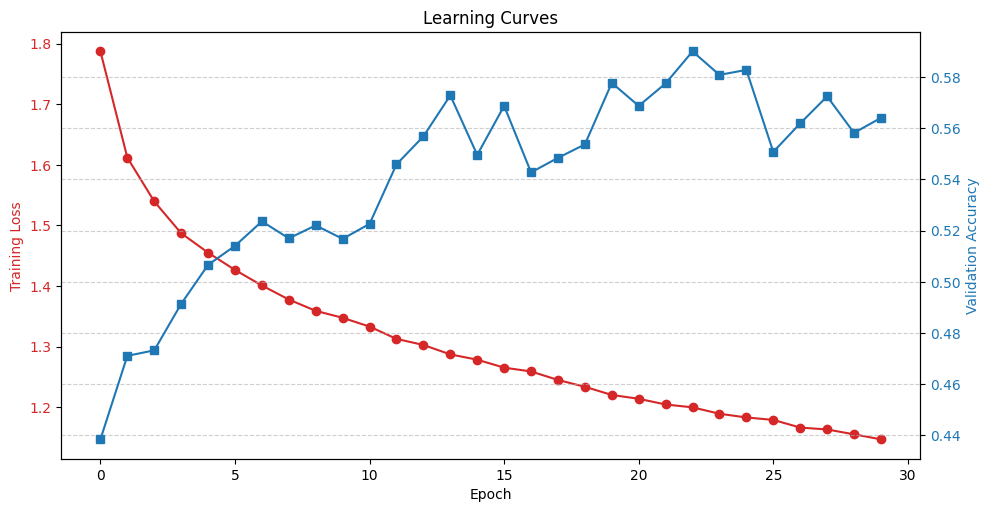

In [22]:
import matplotlib.pyplot as plt

# Plot learning curves
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(train_losses, color=color, marker='o', label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy', color=color)  
ax2.plot(valid_accuracies, color=color, marker='s', label='Valid Acc')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title("Learning Curves")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()